In [1]:
import numpy as np
import matplotlib.pyplot as plt

#### Sampling a single MC

In [2]:
# Params.
N = 10**3

# MC transition rates
mu = 0.5
nu = 0.6

In [3]:
x = np.zeros(N)
x[0] = 0         # Switching between 0 and 1
# We first generate the sequence of random numbers Z_n 
rndm_seq = np.random.uniform(size=N)

for n in range(1, N):
    if (x[n-1] == 0):
        if (rndm_seq[n-1] <= mu):
            x[n] = (x[n-1]+1)%2
        else:
            x[n] = x[n-1]
    else:
        if (rndm_seq[n-1]<=nu):
            x[n] = (x[n-1]+1)%2
        else:
            x[n] = x[n-1]

print("MC generated!")

MC generated!


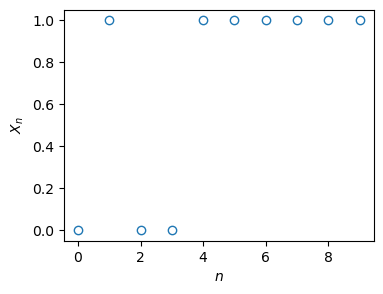

In [4]:
# We plot the MC in time now
plt.figure(figsize=(4,3))

plt.plot(x[0:10], marker = 'o', linestyle = 'none', markerfacecolor='white')

plt.ylabel(r'$X_n$')
plt.xlabel(r'$n$')
plt.show()

#### Sampling an ensemble of MC
We will use same initial condition eventhough the initial condition may be sampled according to the stationary probabilities if one only ones a stationary MC.

In [5]:
# Params.
N = 2*10**2
R = 10**4

# MC transition rates
mu = 0.05
nu = 0.1

In [6]:
x = np.zeros((R, N))
x[:, 0] = 0

for n in range(1, N):
    trials = np.random.uniform(size=R)
    
    mask_0 = x[:, n-1] == 0
    mask_1 = x[:, n-1] == 1
    
    # Construimos máscaras globales (tamaño R)
    jump_0_1 = mask_0 & (trials <= mu)
    stay_0_0 = mask_0 & (trials > mu)
    
    jump_1_0 = mask_1 & (trials <= nu)
    stay_1_1 = mask_1 & (trials > nu)
    
    # Aplicamos directamente sobre x
    x[jump_0_1, n] = 1
    x[stay_0_0, n] = 0
    x[jump_1_0, n] = 0
    x[stay_1_1, n] = 1

print("MCs generated!")

MCs generated!


Probabilities of finding chain at a given state at each iteration $n$.

In [7]:
# We need to find the probability at each iteration
# Since states are 0 and one we only have to sum up and divid by R
p_1_it = np.sum(x, axis=0)/R
p_0_it = 1 - p_1_it

Plotting the evolution of the probabilities. We also paint the stationary probabilities to compare with the dynamic evolution.

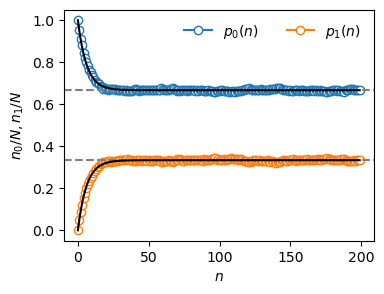

In [8]:
# Plot
plt.figure(figsize=(4,3))

plt.plot(p_0_it, marker = 'o', markerfacecolor='white', label = fr'$p_0(n)$', alpha=1)
plt.plot(p_1_it, marker = 'o', markerfacecolor='white', label = fr'$p_1(n)$', alpha=1)

plt.axhline(mu/(mu+nu), linestyle = '--', color='grey')
plt.axhline(nu/(mu+nu), linestyle = '--', color='grey')

# Probabilities (theory)
p_0_st = mu/(mu+nu)
p_1_st = nu/(mu+nu)
p_0_ini = 0
p_1_ini = 1
n_array = np.linspace(0,N,N)
p_0_n = p_0_st  + (1-(nu+mu))**n_array * (1/(nu+mu))*(nu*p_0_ini - mu*p_1_ini)
p_1_n = p_1_st  - (1-(nu+mu))**n_array * (1/(nu+mu))*(nu*p_0_ini - mu*p_1_ini)
plt.plot(p_0_n, marker = 'none', linestyle = '-', zorder=10, color = 'black')
plt.plot(p_1_n, marker = 'none', linestyle = '-', zorder=10, color = 'black')

plt.legend(loc='upper right', frameon=False, ncol=2)
plt.xlabel(r'$n$')
plt.ylabel(r'$n_0/N, n_1/N$')
plt.show()